# Decision Tree for classification


# 1 Motivation

First of all, **Decision Tree** is a tool for making predicitions. The motivation is to built a flowchart like a tree structure to show how decisions are made in steps. Here is an exmaple (by anshul508). This dataset provides ten observations, and the to-be-predicted (dependent) variable is whether to play golf or not. (Note that this is a classification problem).

> ![eg data](https://editor.analyticsvidhya.com/uploads/905753.png)

Decision trees are nothing but a bunch of if-else statements in layman terms. It checks if the condition is true and if it is then it goes to the next node attached to that decision.
> ![decision tree](https://editor.analyticsvidhya.com/uploads/542834.png)

In the above example, The **root node** is the upmost rectangal labelled by a **feature** called "weather". The root node then **split**s into three **branch**es (a.k.a **subtree**s).  We see that if the weather is cloudy then we must go to play, and it terminates the decision process. Node as such is called a **leaf node**. If, however the weather is sunny, we reach a new **decision node** labelled by a new feature called "humidity".

# 2 How to build (calibrate) a decision tree

Okay, the idea of a decision tree is not hard to understand, but how can we build a decision tree from scratch? Well, you need to have a dataset in the first place.

Since we only focus on a classification decision tree, our goal is to distinguish target=-1 from target=1 using information in the sample. And if the sample is representative, we can use the same tree to make predictions about the population.

With this in mind, we need to develope an algorithm to find the "Best" tree. Or more specifically, **the "Best" sequence of splittings**.

## 2.1 What is "Best"?
To find the best sequence of splitting, we need to first define what is "good". **A "good" splitting should lead to purer and more accurate information**. (If a prediction is invariable 0.5 probability of positive and 0.5 probability of negative, it will add no value to our decision.) .

As an example, consider splitting the origional data using variable "Humidity". After the spliting, 7 observations are in the "High" subset, and 3 of them are labeled "Yes". On the contrary, if we split the original data using "Weather", 3 observations are in the "Cloudy" subset, and all of them have a "Yes" label. Information provided by the "Weather=Cloudy" event is purer than the "Humidity=High" event, and therefore "Weather" maybe a better variable to split the data.

In light of this, we first introduce two measures of information "impurity", so that we can mathematically measure the quality of a splitting.

## 2.2 Measure impurity of a set 1 - Gini impurity

The decision tree construction starts with measuring the "**impurity**" of a single set of data. A split would divide the original sample into several subsamples. If the subsamples are more sorted and organized compared to the original sample, then this is a good split. To measure the sortedness, we take advantage of measures from information science that are used to measure inpurity of a set of data.

We define $S$ as a set of data, and $j = 1,2,..,J$ as all possible labels of the variable (There are two labels: "Yes" and "No" in the example, so $J$=2). $p_j$ denotes the probability of the variable taking label $j$. And if we are dealing with a sample, the empirical probability $p_j$ can be defined as the the number of observations labelled with $j$ divided by the total number of obervations.

$$G(S) = \sum_{j=1}^J p_j(1-p_j)$$

Gini is perhaps the most intuitive measure of inpurity if you are familiar with probability theory. $p_j(1-p_j)$ is the variances of a Bernouli distribution which obtains the largest value when $p_j=0.5$.

## 2.3 Measure of impurity of a set 2 - Entropy

Another commonly used measure of inpurity is the information Entropy, which is formulated as

$$E(S) = \sum_{j=1}^J -p_jlog_2P_j$$

![Entropy Calculation](https://miro.medium.com/max/446/0*BdgOokoatW17zEK7.png)

Both Entropy and Gini impurity obtain the largest value when half of the data are positively labeled. Hence, smaller Entropy or Gini indicates "purer" information.

![Gini vs entropy](https://quantdare.com/wp-content/uploads/2020/11/entropy_and_gini.png)



For a detailed comparision between Gini Impuriy and Entropy, see [this blog](https://quantdare.com/decision-trees-gini-vs-entropy/).

### Why $plogp$?
Step 1: Claude Shannon's definition of self-information was chosen to meet several axioms:
1. An event with probability 100% is perfectly unsurprising and yields no information.
2. The less probable an event is, the more surprising it is and the more information it yields.
3. If two independent events are measured separately, the total amount of information is the sum of the self-informations of the individual events.

Here is one function that satisfies all three criteria:
$$I(E) = -log_b(p(E))$$
Note that surprisal is defined on events, so itself is a random variable (a random experiment creates various outcomes (events) with different probabilities).
Step 2: Information entropy is defined as the expected information of a random experiment.
$$H(X)=\sum p(x)\times-log_b(p(x)) = \sum-plogp$$

## 2.4 Weighted Average Information Impurity and Information Gain

Note that in Section 2.2 and 2.3, the impurity measures are defined on a single set of data. However, in a tree structure, a splitting involes at least 3 datasets - set before the splitting, and 2+ subsets after the splitting.

We define the **information gain** from a splitting $X$ as: E(before X) - weighted average E(after X, subset k). And a natural weight for calculating weighted average is the size (number of observations) of the subset.
$$IG(S,X) = E(S) - \frac{\sum_{k=1}^K n_kE(S_k)}{\sum_{k=1}^K n_k}$$

Apparently, splitting that results in higher information gain is a "better" splitting.

## 2.5 Gini Impurity or Entropy?
So should you use Gini impurity or entropy? The truth is, most of the time it does not make a big difference: they lead to similar trees. Gini impurity is slightly faster to compute, so it is a good default. However, when they differ, Gini impurity tends to isolate the most frequent class in its own branch of the tree, while entropy tends to produce slightly more balanced trees.

## 2.6 Algorithm - Let computers find the "best" according to our definition and measures

Steps in ID3 algorithm:

1. It begins with the original set S as the root node.
2. On each iteration of the algorithm, it iterates through every unused variable of the set S and calculates Entropy(E) and Information gain(IG) of this variable.
3. It then selects the variable (check [this article](https://link.springer.com/content/pdf/10.1023/A:1022638503176.pdf) for splitting of continuous variables) which yields the largest Information gain.
4. The set S is then split by the selected variable to produce a subset of the data.
5. The algorithm continues to recur on each subset, considering only variables never selected before, utill it reaches the preset depth of the tree.

## 2.7 Refined measures

Every measure has pros and cons, and the choice of measure can give us different results.

### Gini Impurity
For example, An algorithm called **CART** (Classification and Regression Tree) uses Gini impurity instead of entropy to create split points. Gini impurity is easier to compute, and there is no agreement on whether Information Gain is better than Gini Index measure. See [Raileanu and  Stoffel](https://www.unine.ch/files/live/sites/imi/files/shared/documents/papers/Gini_index_fulltext.pdf) for a detailed discussion between Gini Index and Information Gain.

### Reduction in Variance
**Reduction in Variance** is a another measure when the target variable is **continuous**, i.e., regression problems. It is so-called because it uses variance as a measure for impurity.
$$\text{Population Variance}(S) = \frac{\sum_{i=1}^n (x_i-\mu)^2}{n}$$

### Chi-Square

In place of Information Gain, there are other measures of splitting quality. For example, The **CHAID** (Chi-square Automatic Interaction Detector) algorithm utilizes the **Chi-square** measure to find the best splitting.
$$\chi^2(S,X) = \sum_{k=1}^K \sum_{j=1}^J \frac{\text{observed number of label j in subset k - expected number of label j in subset k}}{\text{expected number of label j in subset k}}$$
where the $\text{expected number of label j in subset k} = n_k * \frac{\text{number of label j in set S}}{n_S}$

Under the hood, **Chi-square** is a statistic that measures whether two proportions are significantly different. Since proportion is defined for categorical variables, Chi-Square measure can not be applied directly to a continuous target.

### Gain Ratio
Information gain is biased towards choosing variables with a large number of categories.

**C4.5**, an improved algorithm of ID3, uses **Gain ratio** to reduce this bias. Gain ratio overcomes the problem with information gain by taking into account the number of branches that would result before making the split.

$$\text{Gain Ratio} = \frac{IG}{\sum_{i=1}^K w_ilog_2w_i}$$
Where $K$ is the number of branches of a splitting and $w_i=\frac{n_i}{\sum n_i}$

# 3 Python implementation

## 3.1 Train and visualizing a decision tree

To understand Decision Trees, let's just build one and take a look at how it makes predictions. The following code trains a DecisionTreeClassifier on the iris dataset

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()

![iris](https://editor.analyticsvidhya.com/uploads/51518iris%20img1.png)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

X,y = iris.data, iris.target
clf = DecisionTreeClassifier(criterion="gini", max_depth=2)
clf.fit(X,y)

DecisionTreeClassifier(max_depth=2)

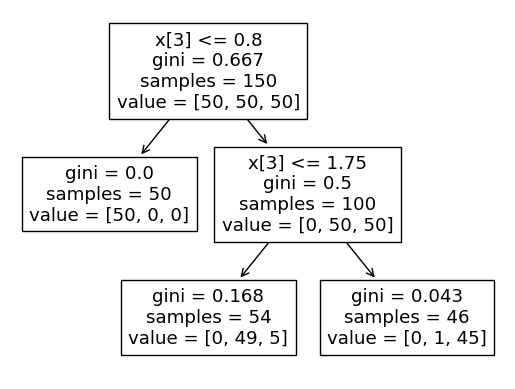

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

tree.plot_tree(clf)
plt.show()

### The Tree object

Please refer to this [documentation](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py) to explore the fitted tree.

In [ ]:
clf.tree_ # return the tree object

In [ ]:
clf.tree_.node_count, clf.tree_.max_depth

(5, 2)

In [ ]:
clf.tree_.feature[0], clf.tree_.threshold[0], clf.tree_.impurity[0], clf.tree_.n_node_samples[0]

(3, 0.800000011920929, 0.6666666666666667, 150)

### Better visualization

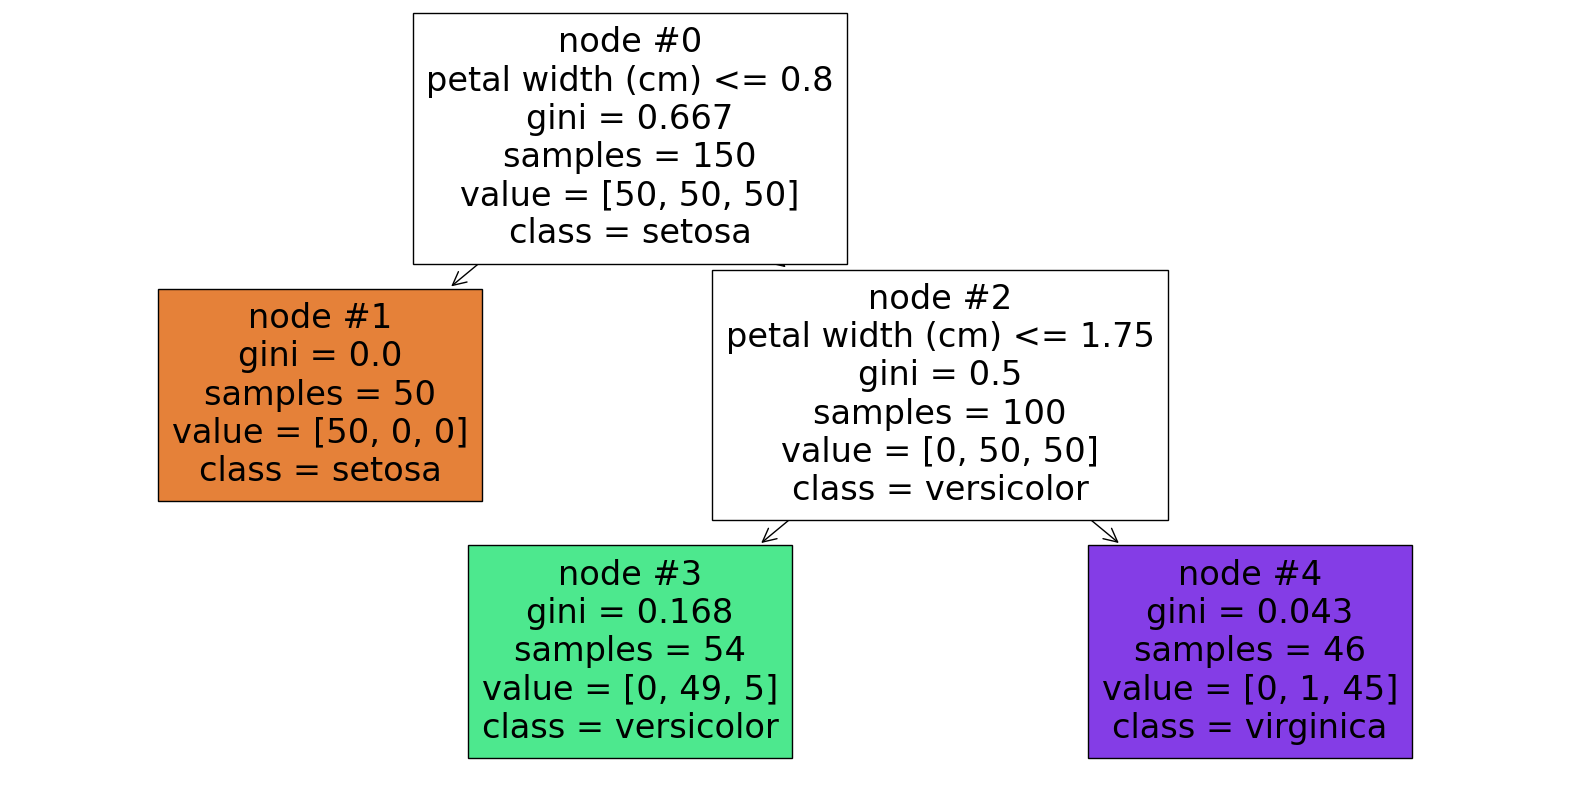

In [ ]:
plt.figure(figsize=(20,10))
tree.plot_tree(clf, filled=True, feature_names=iris["feature_names"], class_names=iris["target_names"], node_ids=True)
plt.show()

In [ ]:
print(f"gini impurity in node 0: {1/3*2/3*3}")
print(f"gini impurity of node 1: {1*(1-1)}")
print(f"gini impurity of node 2: {1/2*1/2*2}")
print(f"weighted gini impurity of depth 1: {50/150*0+100/150*0.5}")
print(f"information gain (reduction in impurity): {-0.333-(-0.667)}")

gini impurity in node 0: 0.6666666666666666
gini impurity of node 1: 0
gini impurity of node 2: 0.5
weighted gini impurity of depth 1: 0.3333333333333333
information gain (reduction in impurity): 0.334


### predictions

In [ ]:
clf.predict(X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2,
       2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Estimating Class Probabilities

A Decision Tree can also estimate the probability that an instance belongs to a particular class k: first it traverses the tree to find the leaf node for this instance, and then it returns the ratio of training instances of class k in this node

In [ ]:
clf.predict_proba([[5,3,1,1]])

array([[0.        , 0.90740741, 0.09259259]])

### feature importance

The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance.

In [ ]:
clf.feature_importances_

array([0., 0., 0., 1.])

In [ ]:
import pandas as pd

pd.DataFrame({"feature":iris["feature_names"],"importance":clf.feature_importances_})

,feature,importance
0,sepal length (cm),0.0
1,sepal width (cm),0.0
2,petal length (cm),0.0
3,petal width (cm),1.0


### Decision boundry (2 features)

[]

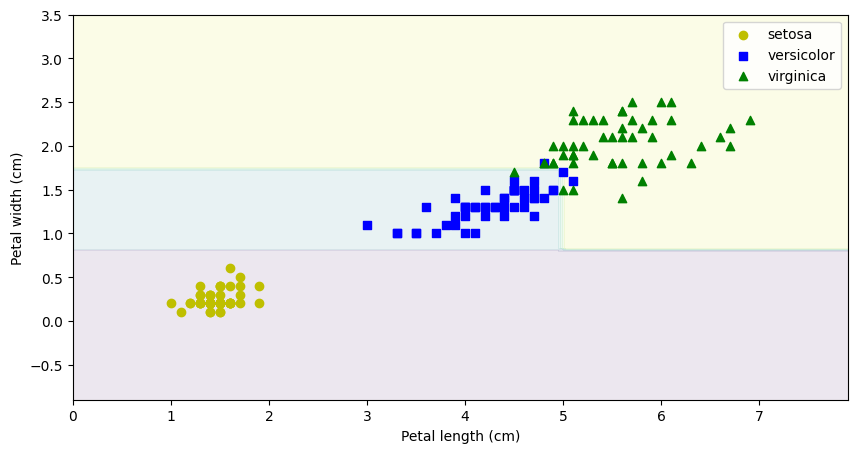

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay
clf2 = DecisionTreeClassifier(max_depth=3)
clf2.fit(X[:,2:],y)

f, ax = plt.subplots(figsize=(10,5))
display = DecisionBoundaryDisplay.from_estimator(
    estimator = clf2,
    X=X[:,2:],
    response_method = "predict", # color based on predicted category
    ax = ax,
    alpha = 0.1
)
names = iris["target_names"]
plt.scatter(X[y==0,2], X[y==0,3], marker="o",color="y", label=names[0])
plt.scatter(X[y==1,2], X[y==1,3], marker="s",color="b", label=names[1])
plt.scatter(X[y==2,2], X[y==2,3], marker="^",color="g", label=names[2])
plt.ylabel("Petal width (cm)")
plt.xlabel("Petal length (cm)")
plt.legend()
plt.plot()


## 3.2 Regularization Hyperparameters

To avoid overfitting the training data, you need to restrict the Decision Tree's freedom during training. As you know by now, this is called regularization. The regularization hyperparameters depend on the algorithm used, but generally you can at least restrict the maximum depth of the Decision Tree. In Scikit-Learn, this is controlled by the **max_depth** hyperparameter (the default value is None, which means unlimited). Reducing max_depth will regularize the model and thus reduce the risk of overfitting.

The DecisionTreeClassifier class has a few other parameters that similarly restrict the shape of the Decision Tree: **min_samples_split** (the minimum number of samples a node must have before it can be split), **min_samples_leaf** (the minimum number of samples a leaf node must have), **max_leaf_nodes** (maximum number of leaf nodes), and **max_features**
(maximum number of features that are evaluated for splitting at each node). Increasing min_* hyperparameters or reducing max_* hyperparameters will regularize the model.

## 3.3 Pruning decision trees

Pruning is one of the mainly used technique to avoid/overcome overfitting, there are generally two types of pruning techniques: pre-pruning and post-pruning.

Prepruning is nothing but stoping the growth of decision tree on an early stage. For that we can limit the growth of trees by setting constrains. We can limit parameters like max_depth , min_samples etc.

Postpruning trims the tree after it is fitted. Cost complexity pruning is one of the most commonly used postpruning techniques.

This algorithm is parameterized by $\alpha$ known as the complexity parameter. The complexity parameter is used to define the cost-complexity measure $R_{\alpha}(T)$ of a given tree :

$$R_{\alpha}(T) = R(T) + \alpha |\tilde{T}|$$

where $|\tilde{T}|$  is the number of terminal nodes in T and $R(T)$ is traditionally defined as the total misclassification rate of the terminal nodes. Alternatively, scikit-learn uses the total sample weighted impurity of the terminal nodes for $R(T)$. This is similar to the regularized linear models where we have a cost funciton and a regularization term parameterized by $\alpha$.


# 4 Regression

Decision Trees are also capable of performing regression tasks. Let's build a regression tree using Scikit-Learn's DecisionTreeRegressor class, training it on a noisy quadratic dataset with max_depth=2:

Decision trees can also be applied to regression problems - when y is continuous. The tree-model and structure will be the same as a classification tree. The only difference is that we can no longer compute Gini Impurity or Information Entropy in the case of regression.

In replace of Gini Impurity, we can use variance of y in each node to measure its impurity. i.e., for each child node, we compute

$$\bar{y} = \frac{1}{n} \sum y_i$$

and

$$ H(node) = Var(node) = \frac{1}{n}\sum (y_i-\bar{y})^2 $$

> Note that in decision tree, we use $\bar{y}$ to predict all observations in that node, so we have $\hat{y}=\bar{y}$. Hence, variance of a node is equivalent to its mean squared error - $1/n\sum(y_i-\hat{y})^2$

We can use the [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor) class to fit a regression Tree. For this example, we use the [diabetes dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) from scikit-learn. Ten baseline variables, age, sex, body mass index, average blood pressure, and six blood serum measurements were obtained for each of n = 442 diabetes patients, as well as the response of interest, a quantitative measure of disease progression one year after baseline.

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
import matplotlib.pyplot as plt
import numpy as np

diab = load_diabetes()
X,y = diab.data, diab.target

In [ ]:
diab.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [ ]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [ ]:
tree_reg = DecisionTreeRegressor(max_depth=2)
tree_reg.fit(X[:,[2]],y) # use bmi to predict y

DecisionTreeRegressor(max_depth=2)

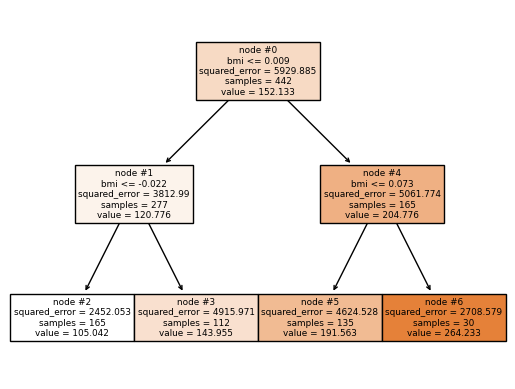

In [ ]:
tree.plot_tree(tree_reg, feature_names=["bmi"], filled=True, node_ids=True)
plt.show()

In [ ]:
tree_reg.tree_.threshold

array([ 0.00942232, -0.02183423, -2.        , -2.        ,  0.07301323,
       -2.        , -2.        ])

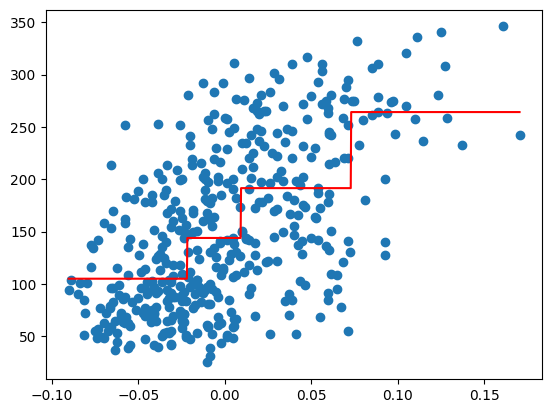

In [ ]:
some_X = np.linspace(np.min(X[:,2]),np.max(X[:,2]),1000)
plt.plot(some_X,tree_reg.predict(some_X.reshape(-1,1)),"r-")
plt.scatter(X[:,2],y)
plt.show()

# 5 Disadvantages - Instability

Hopefully by now you are convinced that Decision Trees have a lot going for them: they are simple to understand and interpret, easy to use, versatile, and powerful. However they do have a few limitations. First, as you may have noticed, Decision Trees love orthogonal decision boundaries (all splits are perpendicular to an axis), which makes them sensitive to training set rotation. One way to limit this problem is to use **PCA**, which often results in a better orientation of the training data.

More generally, the main issue with Decision Trees is that they are very sensitive to small variations in the training data. For example, if you just remove the widest IrisVersicolor from the iris training set (the one with petals 4.8 cm long and 1.8 cm wide) and train a new Decision Tree, you may get a completely different model.

Random Forests can limit this instability by averaging predictions over many trees, as we will see in the next chapter